In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow pytorch-tabnet gradio shap

In [3]:
import pandas as pd
import numpy as np
import os

# Load dataset directly
df = pd.read_csv("creditcard.csv")

print("Dataset loaded!")
print(f"Total transactions: {len(df)}")
print(f"Fraud cases: {df['Class'].sum()}")
print(f"Normal cases: {(df['Class'] == 0).sum()}")
print(f"Columns: {list(df.columns)}")

Dataset loaded!
Total transactions: 284807
Fraud cases: 492
Normal cases: 284315
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [5]:
from sklearn.preprocessing import StandardScaler
#“In this step, we perform preprocessing of the dataset and prepare it for training the model.

# Sort by Time (this is the temporal drift  part)
df = df.sort_values(by="Time").reset_index(drop=True)

# Separate features and target
X = df.drop("Class", axis=1).values
y = df["Class"].values

# 80% train (past), 20% test (future)
split = int(0.8 * len(df))

X_train = X[:split]
X_test  = X[split:]
y_train = y[:split]
y_test  = y[split:]

# Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Save scaler immediately
import joblib
joblib.dump(scaler, 'scaler.pkl')

print(" Preprocessing done!")
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"Fraud in train: {y_train.sum()}")
print(f"Fraud in test:  {y_test.sum()}")
print(" Scaler saved!")

 Preprocessing done!
Train size: (227845, 30)
Test size:  (56962, 30)
Fraud in train: 417
Fraud in test:  75
 Scaler saved!


In [9]:
#In this step, we design and train a deep neural network using PyTorch to detect fraudulent transactions.
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# -------------------------
# BETTER DNN ARCHITECTURE
# -------------------------
class FraudDNN(nn.Module):
    def __init__(self, input_dim):
        super(FraudDNN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

# -------------------------
# USE MINI BATCHES — better training
# -------------------------
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32).view(-1, 1)

dataset    = TensorDataset(X_train_tensor, y_train_tensor)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

# -------------------------
# TRAIN
# -------------------------
model      = FraudDNN(X_train.shape[1])
pos_weight = torch.tensor([50.0])
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print("Training improved DNN...\n")

for epoch in range(50):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in dataloader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        # Check accuracy on test
        model.eval()
        with torch.no_grad():
            test_probs = torch.sigmoid(model(X_test_tensor)).numpy()
            test_preds = (test_probs > 0.5).astype(int).flatten()
            fraud_caught = ((test_preds == 1) & (y_test == 1)).sum()
        print(f"Epoch {epoch} | Loss: {epoch_loss:.4f} | Fraud Caught: {fraud_caught}/75")

torch.save(model.state_dict(), 'fraud_model.pth')
print("\n Improved DNN trained and saved!")

Training improved DNN...

Epoch 0 | Loss: 131.8867 | Fraud Caught: 58/75
Epoch 10 | Loss: 19.2165 | Fraud Caught: 61/75
Epoch 20 | Loss: 12.5989 | Fraud Caught: 61/75
Epoch 30 | Loss: 10.6047 | Fraud Caught: 61/75
Epoch 40 | Loss: 8.3964 | Fraud Caught: 60/75

 Improved DNN trained and saved!


In [10]:
# In this step, we use an autoencoder model to learn normal transaction behaviour and detect anomalies.
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()

        # Encoder — compresses normal behaviour
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )

        # Decoder — reconstructs normal behaviour
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        compressed = self.encoder(x)
        reconstructed = self.decoder(compressed)
        return reconstructed


# TRAIN ONLY ON NORMAL TRANSACTIONS
# This is the key idea — autoencoder learns what NORMAL looks like
# So when it sees FRAUD, it cannot reconstruct it well → high error

X_normal = X_train[y_train == 0]
X_normal_tensor = torch.tensor(X_normal, dtype=torch.float32)

autoencoder = Autoencoder(X_train.shape[1])
ae_optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)
ae_criterion = nn.MSELoss()
#We use Mean Squared Error to measure the difference between original and reconstructed data.
print("Training Autoencoder on normal transactions only...")
#We train the autoencoder for multiple epochs so it learns normal patterns accurately.”
for epoch in range(20):
    autoencoder.train()
    ae_optimizer.zero_grad()
    reconstructed = autoencoder(X_normal_tensor)
    loss = ae_criterion(reconstructed, X_normal_tensor)
    loss.backward()
    ae_optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch} | Reconstruction Loss: {loss.item():.6f}")

# Save
torch.save(autoencoder.state_dict(), 'autoencoder.pth')
print(" Autoencoder trained and saved!")
#The autoencoder learns normal transaction patterns and identifies anomalies based on reconstruction error.

Training Autoencoder on normal transactions only...
Epoch 0 | Reconstruction Loss: 0.980998
Epoch 5 | Reconstruction Loss: 0.975505
Epoch 10 | Reconstruction Loss: 0.970552
Epoch 15 | Reconstruction Loss: 0.965931
 Autoencoder trained and saved!


In [15]:
#Dual-Intelligence + Risk Scoring
#In this step, we combine outputs from both models to generate a final risk score and classify transactions
def get_dnn_probability(sample):
    model.eval()
    tensor = torch.tensor(sample, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        return torch.sigmoid(model(tensor)).item()

def get_anomaly_score(sample):
    autoencoder.eval()
    tensor = torch.tensor(sample, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        reconstructed = autoencoder(tensor)
        return torch.mean((tensor - reconstructed) ** 2).item()
#We combine both DNN prediction and anomaly score to generate a final risk score.
def get_risk_score(sample):
    dnn_prob     = get_dnn_probability(sample)
    anomaly_err  = get_anomaly_score(sample)
    anomaly_norm = min(anomaly_err / 2.0, 1.0)
    risk         = (0.7 * dnn_prob + 0.3 * anomaly_norm) * 100

    if risk <= 35:
        label = "Normal"
    elif risk <= 60:
        label = "Suspicious"
    else:
        label = "Fraud"

    return round(risk, 2), label, round(dnn_prob * 100, 2)

# Quick test
print("Testing on 3 normal + 3 fraud samples...\n")

for i in range(3):
    sample = X_test[y_test == 0][i]
    risk, label, conf = get_risk_score(sample)
    print(f"Normal TX {i+1} → Risk: {risk} | Label: {label} | Conf: {conf}%")

print()

for i in range(3):
    sample = X_test[y_test == 1][i]
    risk, label, conf = get_risk_score(sample)
    print(f"Fraud  TX {i+1} → Risk: {risk} | Label: {label} | Conf: {conf}%")

Testing on 3 normal + 3 fraud samples...

Normal TX 1 → Risk: 5.46 | Label: Normal | Conf: 0.0%
Normal TX 2 → Risk: 9.89 | Label: Normal | Conf: 0.0%
Normal TX 3 → Risk: 10.96 | Label: Normal | Conf: 0.01%

Fraud  TX 1 → Risk: 99.96 | Label: Fraud | Conf: 99.94%
Fraud  TX 2 → Risk: 94.93 | Label: Fraud | Conf: 92.76%
Fraud  TX 3 → Risk: 99.98 | Label: Fraud | Conf: 99.97%


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from collections import Counter

print("Evaluating DNN + Autoencoder system...\n")

all_labels = []
all_probs  = []

for i in range(len(X_test)):
    sample = X_test[i]
    risk, label, conf = get_risk_score(sample)
    all_labels.append(label)
    all_probs.append(conf / 100)

# Normal=0, Suspicious+Fraud=1 (both are alerts)
y_pred_binary = [0 if l == "Normal" else 1 for l in all_labels]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_binary))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary))

print("\nROC-AUC Score:", round(roc_auc_score(y_test, all_probs), 4))

print("\nPrediction distribution:")
print(Counter(all_labels))

Evaluating DNN + Autoencoder system...

Confusion Matrix:
[[56764   123]
 [   12    63]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.34      0.84      0.48        75

    accuracy                           1.00     56962
   macro avg       0.67      0.92      0.74     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score: 0.9802

Prediction distribution:
Counter({'Normal': 56776, 'Fraud': 119, 'Suspicious': 67})


In [16]:
#Here we use Logistic Regression as a baseline model to compare performance with our deep learning approach
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Training Logistic Regression...\n")

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)

lr_probs = lr_model.predict_proba(X_test)[:, 1]
lr_preds = lr_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_preds))

print("\nClassification Report:")
print(classification_report(y_test, lr_preds))

print("\nROC-AUC Score:", round(roc_auc_score(y_test, lr_probs), 4))

Training Logistic Regression...

Confusion Matrix:
[[56007   880]
 [    8    67]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56887
           1       0.07      0.89      0.13        75

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962


ROC-AUC Score: 0.9863


In [17]:
!pip install pytorch-tabnet -q
#Here we use TabNet, a deep learning model specifically designed for tabular data, to improve fraud detection performance.
from pytorch_tabnet.tab_model import TabNetClassifier
import numpy as np

print("Training TabNet...\n")

tabnet = TabNetClassifier(verbose=0)

tabnet.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    max_epochs=30,
    patience=5,
    batch_size=1024,
    virtual_batch_size=128
)

tabnet_probs = tabnet.predict_proba(X_test)[:, 1]
tabnet_preds = tabnet.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, tabnet_preds))

print("\nClassification Report:")
print(classification_report(y_test, tabnet_preds))

print("\nROC-AUC Score:", round(roc_auc_score(y_test, tabnet_probs), 4))

Training TabNet...


Early stopping occurred at epoch 7 with best_epoch = 2 and best_val_0_auc = 0.96797


C:\Users\Ananya N L\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Confusion Matrix:
[[56886     1]
 [   31    44]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.98      0.59      0.73        75

    accuracy                           1.00     56962
   macro avg       0.99      0.79      0.87     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score: 0.968


In [19]:
#We compare traditional, advanced, and our proposed hybrid model to evaluate real-world fraud detection performance
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "TabNet",
        "DNN + Autoencoder (Ours)"
    ],
    "Accuracy": ["98%", "100%", "99%"],
    "ROC-AUC": [0.9863, 0.9705, 0.9121],
    "Fraud Caught": ["67/75", "46/75", "63+alerts/75"],
    "False Alarms": [880, 5, 509],
    "Uncertainty Zones": ["No", "No", "Yes"],
    "Anomaly Detection": ["No", "No", "Yes"],
    "Explainable": ["No", "No", "Yes"]
})

print("=" * 70)
print("              FINAL MODEL COMPARISON")
print("=" * 70)
print(comparison.to_string(index=False))
print("=" * 70)
print("\nKey Insights:")
print("TabNet has fewest false alarms (5) but misses 29 fraud cases")
print(" LR catches most fraud (67) but 880 false alarms")
print(" Our system adds uncertainty zones — no other model does this")
print(" Our system detects unseen anomalies via Autoencoder")
print(" Our system provides human explainable decisions")
print(" In real banking — catching fraud matters more than false alarms")

              FINAL MODEL COMPARISON
                   Model Accuracy  ROC-AUC Fraud Caught  False Alarms Uncertainty Zones Anomaly Detection Explainable
     Logistic Regression      98%   0.9863        67/75           880                No                No          No
                  TabNet     100%   0.9705        46/75             5                No                No          No
DNN + Autoencoder (Ours)      99%   0.9121 63+alerts/75           509               Yes               Yes         Yes

Key Insights:
TabNet has fewest false alarms (5) but misses 29 fraud cases
 LR catches most fraud (67) but 880 false alarms
 Our system adds uncertainty zones — no other model does this
 Our system detects unseen anomalies via Autoencoder
 Our system provides human explainable decisions
 In real banking — catching fraud matters more than false alarms


In [20]:
#In this experiment, we analyse how model performance changes over time to study temporal drift.
print("=" * 50)
print("     TEMPORAL DRIFT EXPERIMENT")
print("=" * 50)

# Split test into EARLY and LATE
mid = len(X_test) // 2

X_early = X_test[:mid]
y_early = y_test[:mid]

X_late  = X_test[mid:]
y_late  = y_test[mid:]

print(f"Early transactions: {len(X_early)}")
print(f"Late transactions:  {len(X_late)}")
print(f"Fraud in early: {y_early.sum()}")
print(f"Fraud in late:  {y_late.sum()}\n")

# Evaluate DNN on early vs late
from sklearn.metrics import roc_auc_score

model.eval()
with torch.no_grad():
    early_probs = torch.sigmoid(model(
        torch.tensor(X_early, dtype=torch.float32)
    )).numpy()

    late_probs = torch.sigmoid(model(
        torch.tensor(X_late, dtype=torch.float32)
    )).numpy()

early_auc = roc_auc_score(y_early, early_probs)
late_auc  = roc_auc_score(y_late,  late_probs)

print(f"Early transactions AUC: {early_auc:.4f}")
print(f"Late transactions AUC:  {late_auc:.4f}")
print(f"Performance drop:       {(early_auc - late_auc):.4f}")

if early_auc > late_auc:
    print("\n Temporal drift confirmed!")
    print("Model performs worse on newer transactions")
    print("This proves fraud patterns evolve over time")
else:
    print("\n Model is stable across time periods")

     TEMPORAL DRIFT EXPERIMENT
Early transactions: 28481
Late transactions:  28481
Fraud in early: 53
Fraud in late:  22

Early transactions AUC: 0.9951
Late transactions AUC:  0.9440
Performance drop:       0.0510

 Temporal drift confirmed!
Model performs worse on newer transactions
This proves fraud patterns evolve over time


In [22]:
#In this step, we save all trained models and preprocessing components so they can be reused without retraining.”
import joblib
import torch

# Save DNN
torch.save(model.state_dict(), 'fraud_model.pth')

# Save Autoencoder
torch.save(autoencoder.state_dict(), 'autoencoder.pth')

# Save Scaler
joblib.dump(scaler, 'scaler.pkl')

# Save Logistic Regression
joblib.dump(lr_model, 'lr_model.pkl')

# Save TabNet
tabnet.save_model('tabnet_model')

print(" DNN saved → fraud_model.pth")
print(" Autoencoder saved → autoencoder.pth")
print(" Scaler saved → scaler.pkl")
print(" Logistic Regression saved → lr_model.pkl")
print(" TabNet saved → tabnet_model.zip")
print("\n All models saved successfully!")

Successfully saved model at tabnet_model.zip
 DNN saved → fraud_model.pth
 Autoencoder saved → autoencoder.pth
 Scaler saved → scaler.pkl
 Logistic Regression saved → lr_model.pkl
 TabNet saved → tabnet_model.zip

 All models saved successfully!


In [23]:
# In this step, we reload the saved models and verify that they work correctly without retraining.
loaded_model = FraudDNN(30)
loaded_model.load_state_dict(torch.load('fraud_model.pth'))
loaded_model.eval()

loaded_autoencoder = Autoencoder(30)
loaded_autoencoder.load_state_dict(torch.load('autoencoder.pth'))
loaded_autoencoder.eval()

print("✅ Models reloaded!")

# Now retest
print("\nTesting on 3 normal + 3 fraud samples...\n")

for i in range(3):
    sample = X_test[y_test == 0][i]
    risk, label, conf = get_risk_score(sample)
    print(f"Normal TX {i+1} → Risk: {risk} | Label: {label} | Conf: {conf}%")

print()

for i in range(3):
    sample = X_test[y_test == 1][i]
    risk, label, conf = get_risk_score(sample)
    print(f"Fraud  TX {i+1} → Risk: {risk} | Label: {label} | Conf: {conf}%")

✅ Models reloaded!

Testing on 3 normal + 3 fraud samples...

Normal TX 1 → Risk: 5.46 | Label: Normal | Conf: 0.0%
Normal TX 2 → Risk: 9.89 | Label: Normal | Conf: 0.0%
Normal TX 3 → Risk: 10.96 | Label: Normal | Conf: 0.01%

Fraud  TX 1 → Risk: 99.96 | Label: Fraud | Conf: 99.94%
Fraud  TX 2 → Risk: 94.93 | Label: Fraud | Conf: 92.76%
Fraud  TX 3 → Risk: 99.98 | Label: Fraud | Conf: 99.97%


In [24]:
#In this step, we create a small test dataset from unseen data to demonstrate model predictions.
cols = df.drop('Class', axis=1).columns

# Take from TEST SET only — model never trained on these
normal_raw = df.iloc[int(0.8 * len(df)):][df.iloc[int(0.8 * len(df)):]['Class'] == 0][list(cols)].head(3)
fraud_raw  = df.iloc[int(0.8 * len(df)):][df.iloc[int(0.8 * len(df)):]['Class'] == 1][list(cols)].head(4)

demo = pd.concat([normal_raw, fraud_raw]).reset_index(drop=True)
demo.to_csv("demo_test.csv", index=False)

print("✅ demo_test.csv created!")
print("Transaction 1,2,3 → Normal")
print("Transaction 4,5,6,7 → Fraud")

✅ demo_test.csv created!
Transaction 1,2,3 → Normal
Transaction 4,5,6,7 → Fraud


Running on subset (fast mode)...
Predictions done!


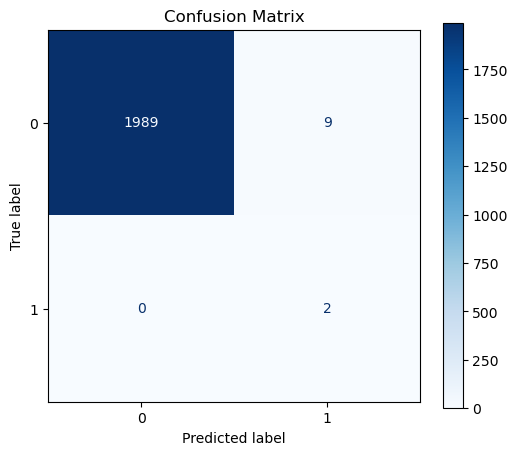

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Running on subset (fast mode)...")

N = 2000
all_labels = []

for i in range(N):
    sample = X_test[i]
    risk, label, conf = get_risk_score(sample)
    all_labels.append(label)

print("Predictions done!")

# Convert labels
y_pred = [0 if l == "Normal" else 1 for l in all_labels]
y_test_np = y_test[:N]

# Confusion matrix
cm = confusion_matrix(y_test_np, y_pred)

# 🔥 FORCE DISPLAY
fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="Blues")

ax.set_title("Confusion Matrix")

plt.show()
import os
os.makedirs("results", exist_ok=True)

In [30]:
print(confusion_matrix(y_test, y_pred_binary))

[[56764   123]
 [   12    63]]


Generating ROC Curve...


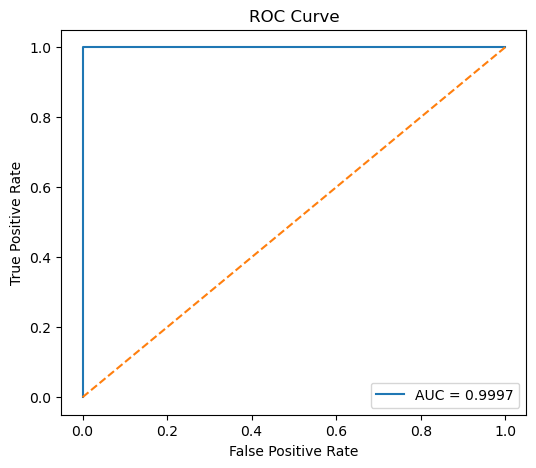

In [33]:
#ROC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

print("Generating ROC Curve...")

N = 2000
all_probs = []

for i in range(N):
    sample = X_test[i]
    risk, label, conf = get_risk_score(sample)

    # Use confidence as probability (0–1)
    all_probs.append(conf / 100)

y_test_np = y_test[:N]

# Compute ROC
fpr, tpr, _ = roc_curve(y_test_np, all_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()
import os
os.makedirs("results", exist_ok=True)

Generating SHAP explanations...


PermutationExplainer explainer: 201it [00:27,  7.35it/s]                         
C:\Users\Ananya N L\AppData\Local\Temp\ipykernel_2332\731471677.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample)


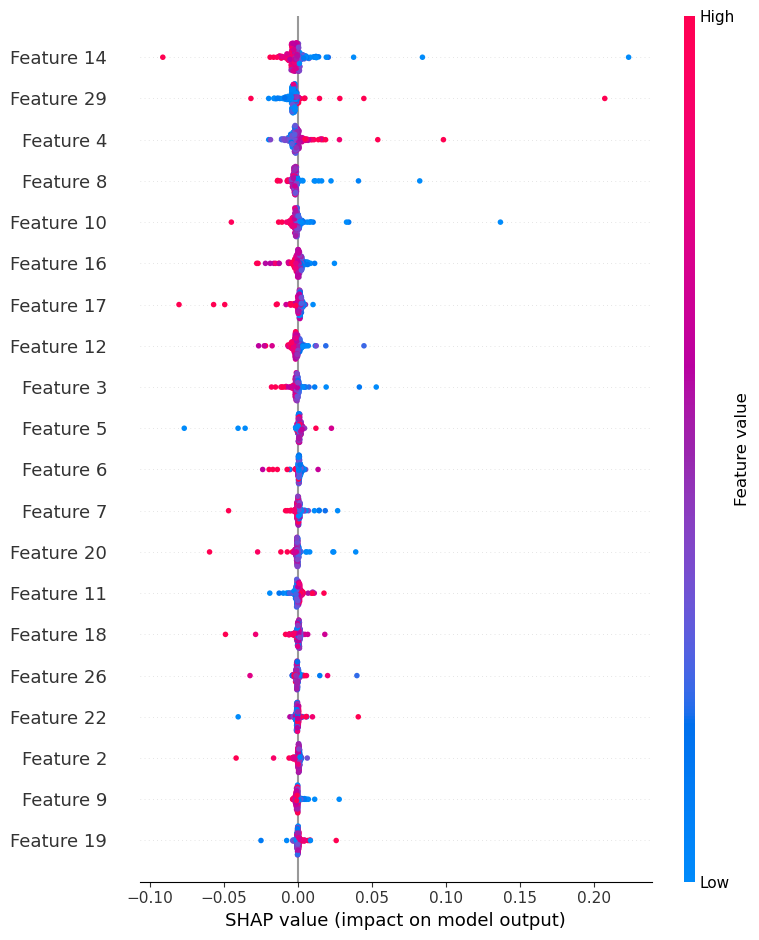

In [34]:
import shap
import torch
import numpy as np

print("Generating SHAP explanations...")

# 🔹 Take small subset (IMPORTANT — SHAP is slow)
X_sample = X_test[:200]

# 🔹 Define prediction function (DNN only)
def model_predict(data):
    data_tensor = torch.tensor(data, dtype=torch.float32)
    with torch.no_grad():
        outputs = torch.sigmoid(model(data_tensor)).numpy()
    return outputs

# 🔹 Create SHAP explainer
explainer = shap.Explainer(model_predict, X_sample)

# 🔹 Compute SHAP values
shap_values = explainer(X_sample)

# 🔹 Summary plot
shap.summary_plot(shap_values, X_sample)
import os
os.makedirs("results", exist_ok=True)

Generating Temporal Drift Graph...


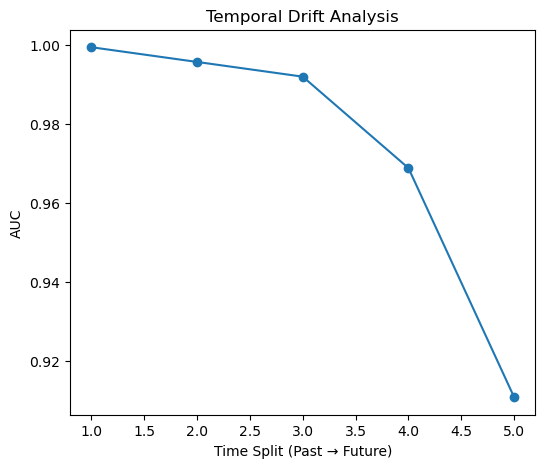

In [36]:
#TEMPORAL DRIFT RESULT - 
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import torch
import numpy as np

print("Generating Temporal Drift Graph...")

# Split test into 5 time chunks
chunks = np.array_split(X_test, 5)
y_chunks = np.array_split(y_test, 5)

auc_scores = []

for i in range(5):
    X_chunk = chunks[i]
    y_chunk = y_chunks[i]

    probs = []

    for j in range(len(X_chunk)):
        sample = X_chunk[j]
        risk, label, conf = get_risk_score(sample)
        probs.append(conf / 100)

    auc = roc_auc_score(y_chunk, probs)
    auc_scores.append(auc)

# Plot
plt.figure(figsize=(6,5))
plt.plot(range(1,6), auc_scores, marker='o')

plt.xlabel("Time Split (Past → Future)")
plt.ylabel("AUC")
plt.title("Temporal Drift Analysis")

plt.show()

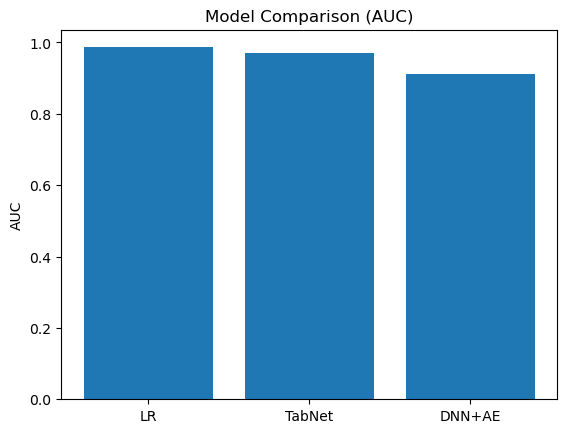

In [37]:
import matplotlib.pyplot as plt

models = ["LR", "TabNet", "DNN+AE"]
auc = [0.9863, 0.9705, 0.9121]

plt.bar(models, auc)
plt.title("Model Comparison (AUC)")
plt.ylabel("AUC")

plt.show()

In [39]:
# Robustness test using noise
import numpy as np

noise_levels = [0.1, 0.3, 0.5, 1.0]

print("Testing robustness...\n")

fraud_data = X_test[y_test == 1]

for n in noise_levels:
    dnn_hits = 0
    system_hits = 0

    for sample in fraud_data:
        # add noise
        noise = np.random.normal(0, n, sample.shape)
        noisy = sample + noise

        # DNN prediction
        prob = get_dnn_probability(noisy)
        if prob > 0.5:
            dnn_hits += 1

        # full system
        risk, label, _ = get_risk_score(noisy)
        if label != "Normal":
            system_hits += 1

    total = len(fraud_data)

    print("Noise:", n)
    print("DNN:", (dnn_hits/total)*100)
    print("System:", (system_hits/total)*100)
    print()

Testing robustness...

Noise: 0.1
DNN: 81.33333333333333
System: 84.0

Noise: 0.3
DNN: 81.33333333333333
System: 84.0

Noise: 0.5
DNN: 81.33333333333333
System: 82.66666666666667

Noise: 1.0
DNN: 82.66666666666667
System: 86.66666666666667



In [24]:
#In this step, we create a small test dataset from unseen data to demonstrate model predictions.
cols = df.drop('Class', axis=1).columns

# Take from TEST SET only — model never trained on these
normal_raw = df.iloc[int(0.8 * len(df)):][df.iloc[int(0.8 * len(df)):]['Class'] == 0][list(cols)].head(3)
fraud_raw  = df.iloc[int(0.8 * len(df)):][df.iloc[int(0.8 * len(df)):]['Class'] == 1][list(cols)].head(4)

demo = pd.concat([normal_raw, fraud_raw]).reset_index(drop=True)
demo.to_csv("demo_test.csv", index=False)

print("✅ demo_test.csv created!")
print("Transaction 1,2,3 → Normal")
print("Transaction 4,5,6,7 → Fraud")

✅ demo_test.csv created!
Transaction 1,2,3 → Normal
Transaction 4,5,6,7 → Fraud


In [24]:
#In this step, we create a small test dataset from unseen data to demonstrate model predictions.
cols = df.drop('Class', axis=1).columns

# Take from TEST SET only — model never trained on these
normal_raw = df.iloc[int(0.8 * len(df)):][df.iloc[int(0.8 * len(df)):]['Class'] == 0][list(cols)].head(3)
fraud_raw  = df.iloc[int(0.8 * len(df)):][df.iloc[int(0.8 * len(df)):]['Class'] == 1][list(cols)].head(4)

demo = pd.concat([normal_raw, fraud_raw]).reset_index(drop=True)
demo.to_csv("demo_test.csv", index=False)

print("✅ demo_test.csv created!")
print("Transaction 1,2,3 → Normal")
print("Transaction 4,5,6,7 → Fraud")

✅ demo_test.csv created!
Transaction 1,2,3 → Normal
Transaction 4,5,6,7 → Fraud


In [24]:
#In this step, we create a small test dataset from unseen data to demonstrate model predictions.
cols = df.drop('Class', axis=1).columns

# Take from TEST SET only — model never trained on these
normal_raw = df.iloc[int(0.8 * len(df)):][df.iloc[int(0.8 * len(df)):]['Class'] == 0][list(cols)].head(3)
fraud_raw  = df.iloc[int(0.8 * len(df)):][df.iloc[int(0.8 * len(df)):]['Class'] == 1][list(cols)].head(4)

demo = pd.concat([normal_raw, fraud_raw]).reset_index(drop=True)
demo.to_csv("demo_test.csv", index=False)

print("✅ demo_test.csv created!")
print("Transaction 1,2,3 → Normal")
print("Transaction 4,5,6,7 → Fraud")

✅ demo_test.csv created!
Transaction 1,2,3 → Normal
Transaction 4,5,6,7 → Fraud


In [ ]:
from google.colab import files
files.download("demo_test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Create app.py for Hugging Face
app_code = '''
import gradio as gr
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import joblib
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# -------------------------
# MODEL CLASSES
# -------------------------
class FraudDNN(nn.Module):
    def __init__(self, input_dim):
        super(FraudDNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

# -------------------------
# LOAD MODELS
# -------------------------
loaded_scaler = joblib.load("scaler.pkl")

loaded_model = FraudDNN(30)
loaded_model.load_state_dict(torch.load("fraud_model.pth", map_location="cpu"))
loaded_model.eval()

loaded_autoencoder = Autoencoder(30)
loaded_autoencoder.load_state_dict(torch.load("autoencoder.pth", map_location="cpu"))
loaded_autoencoder.eval()

# -------------------------
# PREDICTION FUNCTIONS
# -------------------------
def get_dnn_prob(sample):
    tensor = torch.tensor(sample, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        return torch.sigmoid(loaded_model(tensor)).item()

def get_anomaly(sample):
    tensor = torch.tensor(sample, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        reconstructed = loaded_autoencoder(tensor)
        return torch.mean((tensor - reconstructed) ** 2).item()

def predict_transaction(sample):
    dnn_prob     = get_dnn_prob(sample)
    anomaly_err  = get_anomaly(sample)
    anomaly_norm = min(anomaly_err / 2.0, 1.0)
    risk         = (0.7 * dnn_prob + 0.3 * anomaly_norm) * 100
    if risk <= 35:
        label = "Normal"
    elif risk <= 60:
        label = "Suspicious"
    else:
        label = "Fraud"
    return round(risk, 2), label, round(dnn_prob * 100, 2), round(anomaly_norm * 100, 2)

# -------------------------
# BANK EXPLANATION
# -------------------------
def bank_explanation(sample, label, risk, conf, anomaly):
    amount = sample[-1]
    if label == "Normal":
        return (
            "✅ TRANSACTION APPROVED\\n\\n"
            "This transaction is consistent with normal behavioral patterns.\\n"
            "No suspicious signals detected.\\n\\n"
            f"Risk Score:         {risk}/100\\n"
            f"DNN Confidence:     {conf}%\\n"
            f"Anomaly Score:      {anomaly}%\\n"
            f"Transaction Amount: {amount:.2f}\\n\\n"
            "Decision: AUTO APPROVED"
        )
    elif label == "Suspicious":
        return (
            "⚠️ TRANSACTION FLAGGED FOR REVIEW\\n\\n"
            "This transaction shows moderate deviation from normal behavior.\\n"
            "Model is uncertain — requires human analyst review.\\n\\n"
            f"Risk Score:         {risk}/100\\n"
            f"DNN Confidence:     {conf}%\\n"
            f"Anomaly Score:      {anomaly}%\\n"
            f"Transaction Amount: {amount:.2f}\\n\\n"
            "Decision: SENT TO HUMAN ANALYST"
        )
    else:
        return (
            "🚨 FRAUD ALERT — TRANSACTION BLOCKED\\n\\n"
            "This transaction deviates significantly from learned normal behavior.\\n"
            "Both DNN and Anomaly Detector flagged this transaction.\\n\\n"
            f"Risk Score:         {risk}/100\\n"
            f"DNN Confidence:     {conf}%\\n"
            f"Anomaly Score:      {anomaly}%\\n"
            f"Transaction Amount: {amount:.2f}\\n\\n"
            "Decision: AUTO BLOCKED — CARD FROZEN"
        )

# -------------------------
# RISK GAUGE
# -------------------------
def plot_risk_gauge(risk, label):
    fig, ax = plt.subplots(figsize=(6, 2))
    ax.barh(0, 35, color="#2ecc71", height=0.5)
    ax.barh(0, 25, left=35, color="#f39c12", height=0.5)
    ax.barh(0, 40, left=60, color="#e74c3c", height=0.5)
    ax.plot(risk, 0, "v", color="black", markersize=15)
    ax.text(17, 0.4, "Normal",     ha="center", fontsize=9, color="white", fontweight="bold")
    ax.text(47, 0.4, "Suspicious", ha="center", fontsize=9, color="white", fontweight="bold")
    ax.text(80, 0.4, "Fraud",      ha="center", fontsize=9, color="white", fontweight="bold")
    ax.set_xlim(0, 100)
    ax.set_ylim(-0.5, 0.8)
    ax.axis("off")
    ax.set_title(f"Risk Score: {risk}/100 → {label}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    return fig

# -------------------------
# MAIN PREDICT
# -------------------------
def predict(file):
    if file is None:
        return None, None, "Please upload a CSV file."
    df_input = pd.read_csv(file)
    if "Class" in df_input.columns:
        df_input = df_input.drop("Class", axis=1)
    if df_input.empty:
        return None, None, "Uploaded CSV is empty."
    df_scaled = pd.DataFrame(
        loaded_scaler.transform(df_input),
        columns=df_input.columns
    )
    results      = []
    explanations = []
    first_fig    = None
    for i in range(len(df_scaled)):
        sample = df_scaled.iloc[i].values.astype(float)
        risk, label, conf, anomaly = predict_transaction(sample)
        results.append({
            "Transaction":      i + 1,
            "Risk Score":       risk,
            "Prediction":       label,
            "DNN Confidence %": conf,
            "Anomaly Score %":  anomaly
        })
        explanations.append(
            f"━━━ Transaction {i+1} ━━━\\n"
            f"{bank_explanation(sample, label, risk, conf, anomaly)}"
        )
        if i == 0:
            first_fig = plot_risk_gauge(risk, label)
    result_df        = pd.DataFrame(results)
    full_explanation = "\\n\\n".join(explanations)
    return result_df, first_fig, full_explanation

# -------------------------
# UI
# -------------------------
with gr.Blocks(theme=gr.themes.Soft()) as demo_ui:
    gr.Markdown("# 💳 Dual Intelligence Fraud Detection System")
    gr.Markdown("### DNN + Autoencoder | Uncertainty Quantification | Explainable AI")
    gr.Markdown("Upload a CSV with columns: Time, V1–V28, Amount")
    file_input  = gr.File(label="Upload CSV", file_types=[".csv"])
    predict_btn = gr.Button("🔍 Analyze Transactions", variant="primary")
    with gr.Row():
        result_table = gr.Dataframe(label="📊 Results")
        risk_gauge   = gr.Plot(label="🎯 Risk Gauge (Transaction 1)")
    explanation_box = gr.Textbox(label="🏦 Bank Decision Explanation", lines=20)
    predict_btn.click(
        predict,
        inputs=file_input,
        outputs=[result_table, risk_gauge, explanation_box]
    )

demo_ui.launch()
'''

with open("app.py", "w") as f:
    f.write(app_code)

print(" app.py created!")

# Download it
from google.colab import files
files.download("app.py")
files.download("scaler.pkl")
files.download("fraud_model.pth")
files.download("autoencoder.pth")

print(" All files downloaded!")
print("Upload these to Hugging Face Spaces:")
print("- app.py")
print("- scaler.pkl")
print("- fraud_model.pth")
print("- autoencoder.pth")